# DBSCAN VS OPTICS Clustering:

DBSCAN and OPTICS are both density-based clustering algorithms used in unsupervised machine learning. They are designed to identify clusters of varying shapes and sizes in datasets, particularly when the clusters are not well-separated.

**`DBSCAN`** (Density-Based Spatial Clustering of Applications with Noise):
DBSCAN groups together points that are closely packed together while marking points that lie alone in low-density regions as outliers. It requires two parameters: epsilon (ε), which defines the radius of the neighborhood around a point, and minPts, which specifies the minimum number of points required to form a dense region. DBSCAN is effective for datasets with noise and can find clusters of arbitrary shapes.

**`Steps to implement DBSCAN:`**
1. Choose the parameters epsilon (ε) and minPts.
2. For each point in the dataset, identify its ε-neighborhood (all points within distance ε).
3. If the ε-neighborhood contains at least minPts, mark the point as a core point and form a cluster.
4. If the ε-neighborhood contains fewer than minPts, mark the point as a border point or noise.
5. Repeat the process for all points, expanding clusters as new core points are found.
   
**`Parameter`**:
- **Epsilon (ε)**: The maximum distance between two points for them to be considered as neighbors.
- **minPts**: The minimum number of points required to form a dense region (cluster).

**`Points`**
- **Core Points**: Points that have at least minPts within their ε-neighborhood.
- **Border Points**: Points that are within the ε-neighborhood of a core point but
- do not have enough neighbors to be core points themselves.
- **Noise Points**: Points that are neither core points nor border points and are considered outliers.

**`OPTICS`** (Ordering Points To Identify the Clustering Structure):
OPTICS is an extension of DBSCAN that addresses some of its limitations. Instead of requiring a fixed epsilon value, OPTICS creates a reachability plot that allows for the identification of clusters at different density levels. This makes it more flexible in discovering clusters of varying densities.

**`Steps to implement OPTICS:`**

1. For each point in the dataset, calculate its core distance (the distance to its min
2. Pts-th nearest neighbor) and reachability distance (the distance to the nearest core point).
3. Sort the points based on their reachability distances, creating a reachability plot.
4. Identify clusters by analyzing the reachability plot, where valleys represent dense regions (clusters) and peaks represent sparse regions (noise).



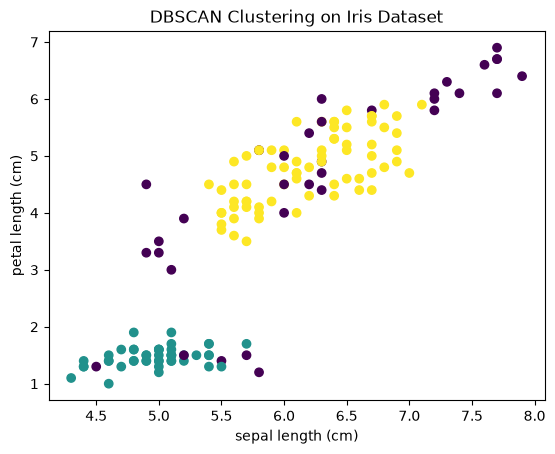

In [1]:
# Import libraries
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create the DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit the model to the data
dbscan.fit(X_scaled)

# Plot the data points with color-coded cluster labels
plt.scatter(X[:, 0], X[:, 2], c=dbscan.labels_, cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("DBSCAN Clustering on Iris Dataset")
plt.show()

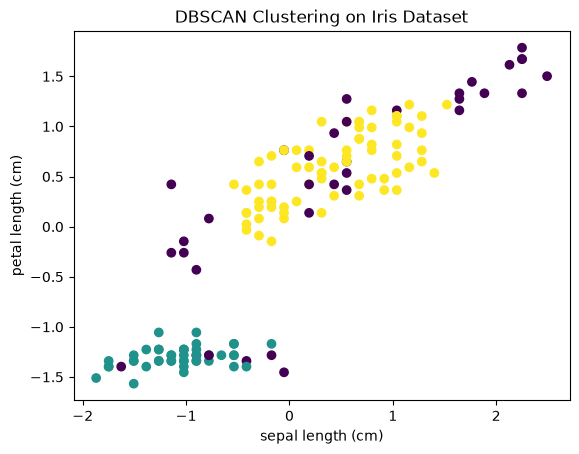

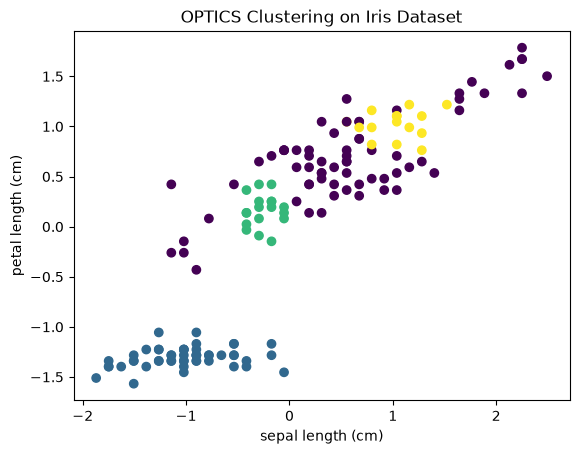

In [18]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
df = sns.load_dataset('iris')

# selecting the features for clustering
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# Standardize the data
X = StandardScaler().fit_transform(X)

# Create the DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# apply optics clustering
optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
optics_labels = optics.fit_predict(X)

# Plot the data points with color-coded cluster labels
plt.scatter(X[:, 0], X[:, 2], c=dbscan.labels_, cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("DBSCAN Clustering on Iris Dataset")
plt.show()

# plot the data points with color-coded cluster labels for OPTICS
plt.scatter(X[:, 0], X[:, 2], c=optics.labels_, cmap='viridis')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("OPTICS Clustering on Iris Dataset")
plt.show()

# Hyperparameters For DBSACN:
A `k-distance` graph can be used to determine the optimal value of epsilon (ε) for DBSCAN. The k-distance graph plots the distance to the k-th nearest neighbor for each point in the dataset. The "elbow" point in the graph indicates a suitable value for ε, where the distance starts to increase significantly.

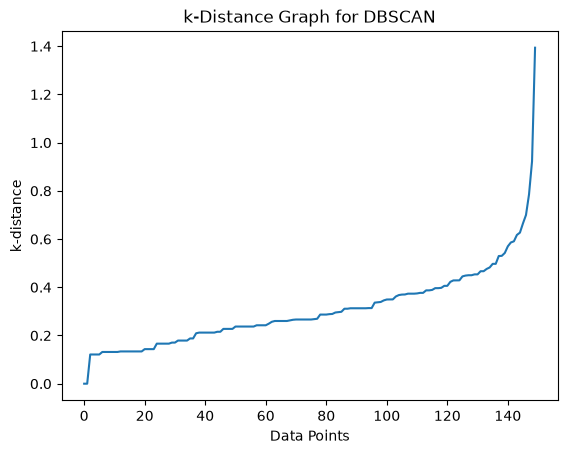

In [4]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
df = sns.load_dataset('iris')

# selecting the features for clustering
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# Standardize the data
X = StandardScaler().fit_transform(X)

# find the nearest neighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)        
distances, indices = neighbors_fit.kneighbors(X)

# sort the distance
distances = np.sort(distances, axis=0)
distances = distances[:,1]

# Plot the k-distance graph
plt.plot(distances)
plt.xlabel('Data Points')
plt.ylabel('k-distance')
plt.title('k-Distance Graph for DBSCAN')
plt.show()


# How to find the MInPTs for DBSCAN:
The minPts parameter can be determined based on the dimensionality of the dataset. A common rule
    of thumb is to set minPts to be at least the number of dimensions plus one (minPts ≥ D + 1). For example, in a 2D dataset, minPts should be at least 3. However, this value can be adjusted based on the specific characteristics of the data and the desired clustering results.

In [16]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load the Iris dataset
df = sns.load_dataset('iris')

# selecting the features for clustering
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# Standardize the data
X = StandardScaler().fit_transform(X)

# Dwfinw the range 'minpts'
minPts_range = range(2, 11)  # Example range for minPts from 2 to 10

# intialize a list to store the elbow points for each minPts value
best_minpts = -1
best_silhouette = -float('inf')

# Grid search over the range of minPts values
for minPts in minPts_range:
    dbscan = DBSCAN(eps=0.5, min_samples=minPts)
    dbscan_labels = dbscan.fit_predict(X)

    # ignore noise points for silhouette score calculation
    non_noise_mask = dbscan_labels != -1
    if non_noise_mask.any():
        filtered_labels = dbscan_labels[non_noise_mask]
        filtered_X = X[non_noise_mask]

        if len(set(filtered_labels)) > 1 and len(filtered_labels) >= 2:
            silhouette_avg = silhouette_score(filtered_X, filtered_labels)
            print(f"minPts: {minPts}, Silhouette Score: {silhouette_avg}")

        if silhouette_avg > best_silhouette:
            best_silhouette = silhouette_avg
            best_minpts = minPts

print(f"Best minPts: {best_minpts} with Silhouette Score: {best_silhouette}")


minPts: 2, Silhouette Score: 0.19038368261424057
minPts: 3, Silhouette Score: 0.2591217055088424
minPts: 4, Silhouette Score: 0.6550064109234347
minPts: 5, Silhouette Score: 0.6558885287002018
minPts: 6, Silhouette Score: 0.4658793456587674
minPts: 7, Silhouette Score: 0.43603415444504434
minPts: 8, Silhouette Score: 0.6028694923383575
minPts: 9, Silhouette Score: 0.539395782932637
minPts: 10, Silhouette Score: 0.7100881808026526
Best minPts: 10 with Silhouette Score: 0.7100881808026526
